In [ ]:
from datetime import datetime as dt
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

pd.set_option('display.width', 1000)
pickle_df = pd.read_pickle('../stats-all-latest.pkl')
millis_in_day = 1000 * 60 * 60 * 24
expected_datapoints_in_day = 24 * 12 * 2 * 2 * 3 * 3 * 3 # hours * executions * clouds * images * formats * widths * memory

# First and last executions, timestamp is in millis
min_ts = pickle_df["timestamp"].min()
max_ts = pickle_df["timestamp"].max()
day_0 = min_ts - min_ts % millis_in_day

print(f'Day 0 start:      {dt.fromtimestamp(day_0/1000)}')
print(f'First timestamp:  {dt.fromtimestamp(min_ts/1000)}')
print(f'Last timestamp:   {dt.fromtimestamp(max_ts/1000)}')
print('')

# start_ts = 1733184000000 # Tue Dec 03 2024 00:00:00 GMT+0000
# end_ts   = 1738540800000 # Mon Feb 03 2025 00:00:00 GMT+0000
start_ts = 1733529600000 # Sat Dec 07 2024 00:00:00 GMT+0000
end_ts   = 1738886400000 # Fri Feb 07 2025 00:00:00 GMT+0000

print(f'Experiment start: {dt.fromtimestamp(start_ts/1000)}')
print(f'Experiment end:   {dt.fromtimestamp(end_ts/1000)}')

days = int((end_ts - start_ts) / millis_in_day)
print(f'Experiment days:  {days}\n')

df = pickle_df.loc[(pickle_df['timestamp'] >= start_ts) & (pickle_df['timestamp'] < end_ts)].copy()

expected_datapoints = int(expected_datapoints_in_day * days)
actual_datapoints = len(df)
missing_datapoints = expected_datapoints-actual_datapoints

print(f'Expected datapoints: {expected_datapoints}')
print(f'Actual datapoints:   {actual_datapoints}, {actual_datapoints/expected_datapoints:.2%}')
print(f'Missing datapoints:  {missing_datapoints}, {missing_datapoints/expected_datapoints:.2%}')
print('')
print(f'Expected datapoints per day: {expected_datapoints_in_day}')
print(f'Actual datapoints per day:   {actual_datapoints/days:.2f}')
print(f'Missing datapoints per day:  {missing_datapoints/days:.2f}')

Day 0 start:      2024-12-02 00:00:00
First timestamp:  2024-12-02 18:40:58.296000
Last timestamp:   2025-02-08 17:23:41.984000

Experiment start: 2024-12-07 00:00:00
Experiment end:   2025-02-07 00:00:00
Experiment days:  62

Expected datapoints: 1928448
Actual datapoints:   1924484, 99.79%
Missing datapoints:  3964, 0.21%

Expected datapoints per day: 31104
Actual datapoints per day:   31040.06
Missing datapoints per day:  63.94


In [ ]:
# Missing executions
data.loc[:, 'isoDate'] = pd.to_datetime(data['!isoDate']) 
data = data.set_index("isoDate").sort_index()



#### Handler counts by cloud

Cloud: aws
                               mean   p50   p95   p99  max
providerMemoryAssociated                                  
885                       12.589098  12.0  24.0  27.0   28
1769                      12.584455  12.0  24.0  27.0   28
3538                      12.582164  12.0  24.0  27.0   28
Expected datapoints from aws: 964224
Actual datapoints from aws:   961113, 99.68%
Missing datapoints from aws:  3111, 0.32%


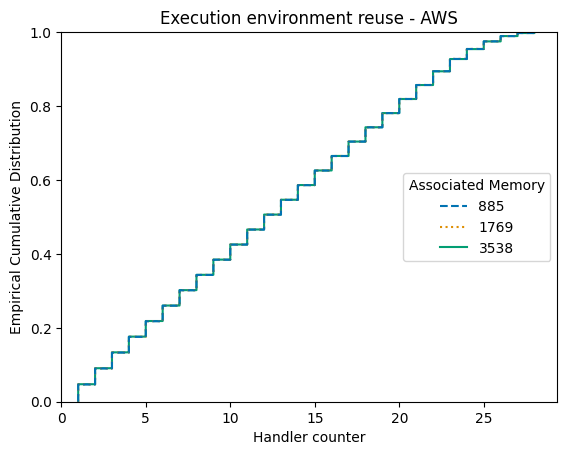

Cloud: gcp
                                 mean    p50     p95      p99   max
providerMemoryAssociated                                           
885                       1354.583347  780.0  4916.0  5716.00  5955
1769                      1357.723005  800.0  4870.0  5721.00  5952
3538                      1300.246493  769.0  4678.0  5616.97  5953
Expected datapoints from gcp: 964224
Actual datapoints from gcp:   963371, 99.91%
Missing datapoints from gcp:  853, 0.09%


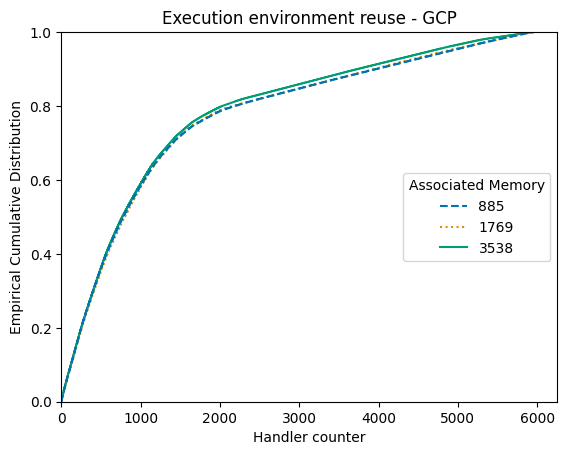

In [ ]:
import seaborn as sns
expected_datapoints_from_cloud = int(expected_datapoints/2)

for cloud in ["aws", "gcp"]:
    print(f"Cloud: {cloud}")
    data = df.loc[(df["providerName"] == cloud)]
    print(data.groupby(["providerMemoryAssociated"]).agg(
        mean=('handlerCount', 'mean'),
        p50=('handlerCount', lambda x: x.quantile(0.50)),
        p95=('handlerCount', lambda x: x.quantile(0.95)),
        p99=('handlerCount', lambda x: x.quantile(0.99)),
        max=('handlerCount', 'max')
    ))

    actual_datapoints_from_cloud = len(data)
    missing_datapoints_from_cloud = expected_datapoints_from_cloud-actual_datapoints_from_cloud
    print(f'Expected datapoints from {cloud}: {expected_datapoints_from_cloud}')
    print(f'Actual datapoints from {cloud}:   {actual_datapoints_from_cloud}, {actual_datapoints_from_cloud/expected_datapoints_from_cloud:.2%}')
    print(f'Missing datapoints from {cloud}:  {missing_datapoints_from_cloud}, {missing_datapoints_from_cloud/expected_datapoints_from_cloud:.2%}')

    
    ax = sns.ecdfplot(
        data,
        x="handlerCount",
        hue="providerMemoryAssociated",
        palette="colorblind",
    )

    # Change linestyle
    lss = ["solid", "dotted", "dashed"]
    handles = ax.legend_.legend_handles[::-1]

    for line, ls, handle in zip(ax.lines, lss, handles):
        line.set_linestyle(ls)
        handle.set_ls(ls)

    ax.get_legend().set_title("Associated Memory")
    plt.title(f"Execution environment reuse - {cloud.upper()}")
    plt.ylabel("Empirical Cumulative Distribution")
    plt.xlabel("Handler counter")
    plt.xlim(0,)
    sns.move_legend(ax, "center right")
    ax.get_figure().savefig(f'../graphs/1-handler-counts-{cloud}.pdf', bbox_inches='tight')
    plt.show()
    plt.close()